## Exploratory Data Analysis

 1. Preliminary data preprocessing

In [24]:
import pandas as pd

df = pd.read_csv(r'C:\Users\c\OneDrive\Documents\PEROVSKITE PROJECT\PerovskiteML_project\Data\Perovsite database query.csv')

# remove rows where the perovskite composition is not ABC3 structure
# remove rows where JV_measured is False

df = df[df['Perovskite_composition_perovskite_ABC3_structure']]

df = df[df['JV_measured']]


# only keep columns of interest (stack parameters and key metrics)
# define columns to keep

columns_to_keep = [
    'Cell_stack_sequence', 'Cell_architecture',
    'Substrate_stack_sequence',
    'ETL_stack_sequence', 'ETL_thickness', 'ETL_additives_compounds',
    'Perovskite_composition_a_ions', 'Perovskite_composition_a_ions_coefficients', 
    'Perovskite_composition_b_ions', 'Perovskite_composition_b_ions_coefficients',
    'Perovskite_composition_c_ions', 'Perovskite_composition_c_ions_coefficients', 
    'Perovskite_composition_short_form', 'Perovskite_composition_long_form', 'Perovskite_composition_leadfree', 'Perovskite_composition_inorganic',
    'Perovskite_additives_compounds', 'Perovskite_additives_concentrations', 'Perovskite_thickness', 'Perovskite_band_gap',
    'HTL_stack_sequence', 'HTL_thickness_list', 'HTL_additives_compounds',
    'Backcontact_stack_sequence',
    'Encapsulation', 'Encapsulation_stack_sequence', 'JV_default_PCE',
    'JV_default_Voc', 'JV_default_Jsc', 'JV_default_FF', 'JV_hysteresis_index', 'Stability_PCE_end_of_experiment'
    ]

filtered_df = df[columns_to_keep]

# Create a new column 'Layer_Type' to indicate if the row is multilayered or single-layered

ion_columns = [
    'Perovskite_composition_a_ions', 'Perovskite_composition_a_ions_coefficients', 
    'Perovskite_composition_b_ions', 'Perovskite_composition_b_ions_coefficients',
    'Perovskite_composition_c_ions', 'Perovskite_composition_c_ions_coefficients'
]

filtered_df['Layer Type'] = filtered_df.apply(
    lambda row: 'Multi-layered Perovskite' if any('|' in str(row[col]) for col in ion_columns) else 'Single-layered Perovskite',
    axis=1
)

output_file_path = 'filtered_original_data.csv'

filtered_df.to_csv(output_file_path, index=False)

print('filtered df saved to csv')

C:\Users\c\AppData\Local\Temp\ipykernel_9728\2740683690.py:3: DtypeWarning: Columns (10,22,29,31,32,35,36,40,44,45,46,48,51,54,65,84,89,90,93,98,99,100,105,108,115,118,122,123,125,130,134,138,142,143,144,146,149,152,163,166,167,171,172,173,175,178,181,192,194,225,271,272,273,277,304,315,321,325,330,331,335,336,342,348,369,371,373,374,376,380,384,387,403,405,407,409) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(r'C:\Users\c\OneDrive\Documents\PEROVSKITE PROJECT\PerovskiteML_project\Data\Perovsite database query.csv')
C:\Users\c\AppData\Local\Temp\ipykernel_9728\2740683690.py:41: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_df['Layer Type'] = filtered_df.apply(


filtered df saved to csv


In [52]:
# how to deal with multi-layered perovskites?

# band gap preprocessing

# import re
# # Function to extract the first float from a cell
# def extract_first_float(cell):
#     # Convert the cell to a string and use regex to find the first float
#     matches = re.findall(r"\d+\.\d+", str(cell))
#     return float(matches[0]) if matches else None  # Return the first match or None

# # Apply the function to the column
# filtered_df['Perovskite_band_gap'] = filtered_df['Perovskite_band_gap'].apply(extract_first_float)

#filter df for only single-layered perovskites
filtered_df = filtered_df[filtered_df['Layer Type'] == 'Single-layered perovskite']
filtered_df = filtered_df[filtered_df['Cell_architecture'] == 'pin']

2. Distributions of key metrics (univariate analysis)

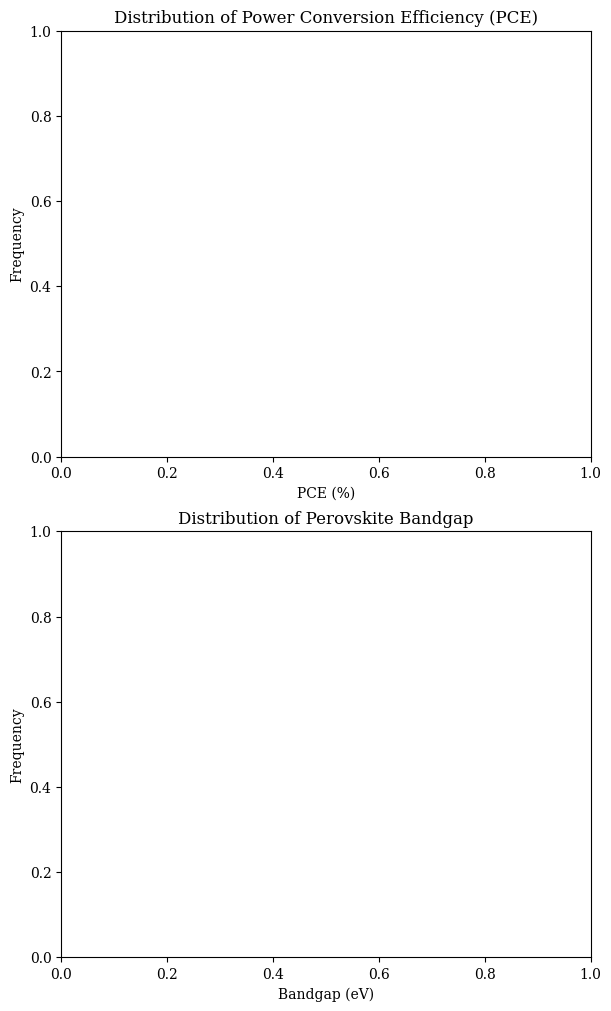

In [54]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Create figure with 1 row, 2 columns
fig, axes = plt.subplots(2, 1, figsize=(6, 10), constrained_layout=True)

# PCE Histogram (Default Binning)
sns.histplot(filtered_df['JV_default_PCE'], kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Distribution of Power Conversion Efficiency (PCE)')
axes[0].set_xlabel('PCE (%)')
axes[0].set_ylabel('Frequency')

# Bandgap Histogram (Custom Binning at 0.1 eV granularity)
filtered_df['Perovskite_band_gap'] = pd.to_numeric(filtered_df['Perovskite_band_gap'], errors='coerce')
# bins = np.arange(filtered_df['Perovskite_band_gap'].min(), filtered_df['Perovskite_band_gap'].max() + 0.1, 0.1)
sns.histplot(filtered_df['Perovskite_band_gap'], kde=True, ax=axes[1], color='purple')
axes[1].set_title('Distribution of Perovskite Bandgap')
axes[1].set_xlabel('Bandgap (eV)')
axes[1].set_ylabel('Frequency')

# Show plot
plt.show()



3. Correlations (bivariate analysis)

C:\Users\c\AppData\Local\Temp\ipykernel_9728\2810881642.py:6: DtypeWarning: Columns (18,19) have mixed types. Specify dtype option on import or set low_memory=False.
  filtered_df = pd.read_csv(r'C:\Users\c\OneDrive\Documents\PEROVSKITE PROJECT\PerovskiteML_project\EDA\filtered_original_data.csv')


Correlation coefficient between JV_default_Voc and JV_default_PCE: 0.60
Correlation coefficient between JV_default_Jsc and JV_default_PCE: 0.81
Correlation coefficient between JV_default_FF and JV_default_PCE: 0.75


ValueError: could not convert string to float: '1.63 | nan'

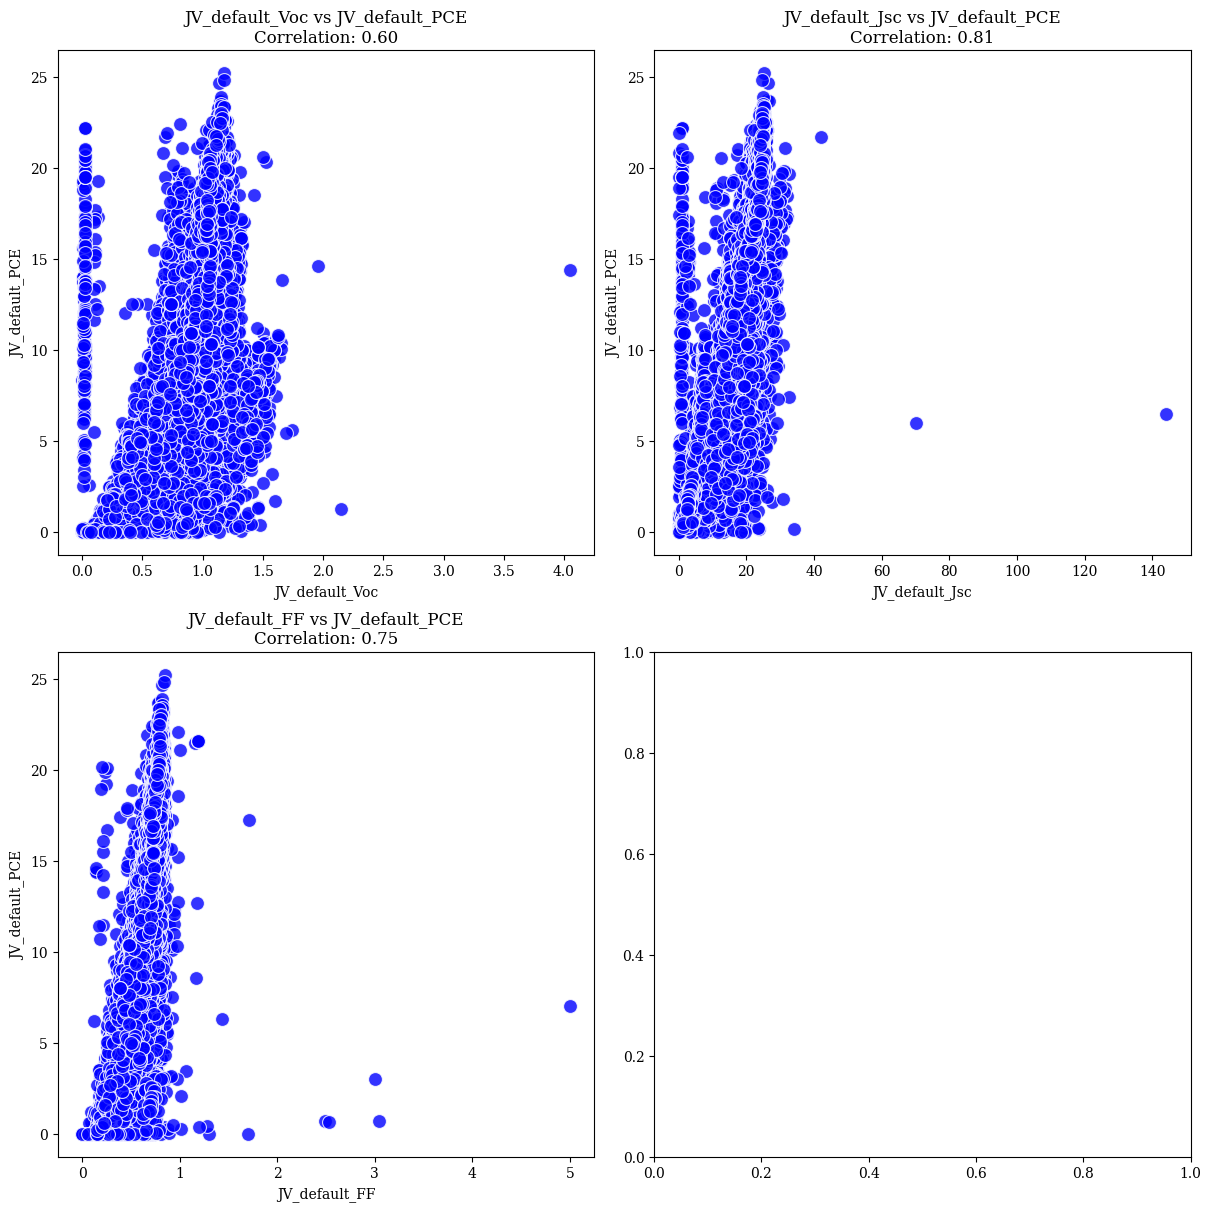

In [61]:
# correlation between bandgap (filtered for single layer) and pce

import pandas as pd

# Load the CSV file into a DataFrame
filtered_df = pd.read_csv(r'C:\Users\c\OneDrive\Documents\PEROVSKITE PROJECT\PerovskiteML_project\EDA\filtered_original_data.csv')

# # Now you can filter it
# filtered_df = filtered_df[filtered_df['Layer Type'] == 'Single-layered perovskite']

# edit to handle multilayered
import matplotlib.pyplot as plt
import seaborn as sns

# Specify the columns to plot
plots = [
    ('JV_default_Voc', 'JV_default_PCE'),
    ('JV_default_Jsc', 'JV_default_PCE'),
    ('JV_default_FF', 'JV_default_PCE'),
    ('Perovskite_band_gap', 'JV_default_PCE')
]

# Set up the figure with subplots: 2 rows, 2 columns
fig, axes = plt.subplots(2, 2, figsize=(12, 12), constrained_layout=True)

# Flatten the axes array for easy indexing
axes = axes.flatten()

# Create scatter plots for each pair of columns
for i, (x_col, y_col) in enumerate(plots):
    # Calculate the correlation coefficient
    correlation = filtered_df[[x_col, y_col]].corr().iloc[0, 1]
    print(f"Correlation coefficient between {x_col} and {y_col}: {correlation:.2f}")
    
    # Create the scatter plot
    sns.scatterplot(data=filtered_df, x=x_col, y=y_col, ax=axes[i], s=100, alpha=0.8, color='blue')
    
    # Add title and labels, including the correlation coefficient
    axes[i].set_title(f'{x_col} vs {y_col}\nCorrelation: {correlation:.2f}', fontsize=12)
    axes[i].set_xlabel(x_col, fontsize=10)
    axes[i].set_ylabel(y_col, fontsize=10)

# Adjust layout and display the plots
plt.suptitle('Scatter Plots of Various Variables vs JV_default_PCE', fontsize=16)
plt.show()

print(filtered_df.head())

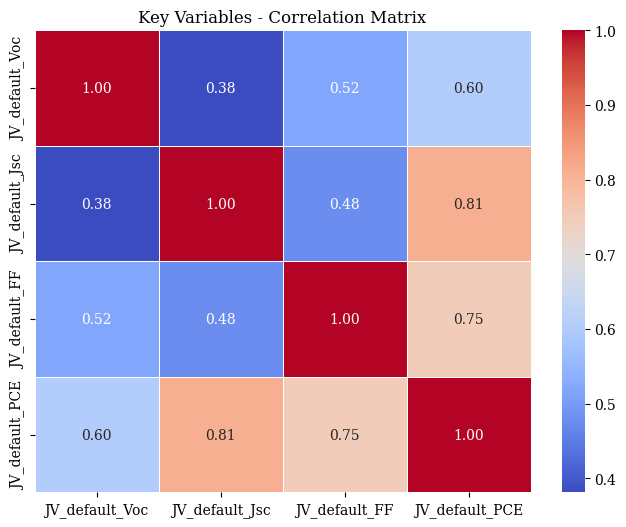

In [64]:
correlation_matrix = filtered_df[['JV_default_Voc', 'JV_default_Jsc', 'JV_default_FF', 'JV_default_PCE']].corr()

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Key Variables - Correlation Matrix")
plt.show()


4. Unique perovskite composition counts

C:\Users\c\AppData\Local\Temp\ipykernel_9728\1517282607.py:6: DtypeWarning: Columns (10,22,29,31,32,35,36,40,44,45,46,48,51,54,65,84,89,90,93,98,99,100,105,108,115,118,122,123,125,130,134,138,142,143,144,146,149,152,163,166,167,171,172,173,175,178,181,192,194,225,271,272,273,277,304,315,321,325,330,331,335,336,342,348,369,371,373,374,376,380,384,387,403,405,407,409) have mixed types. Specify dtype option on import or set low_memory=False.
  filtered_df = pd.read_csv(r'C:\Users\c\OneDrive\Documents\PEROVSKITE PROJECT\PerovskiteML_project\Data\Perovsite database query.csv')
C:\Users\c\AppData\Local\Temp\ipykernel_9728\1517282607.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=plot_data, x=col, y='proportion', palette=palette)


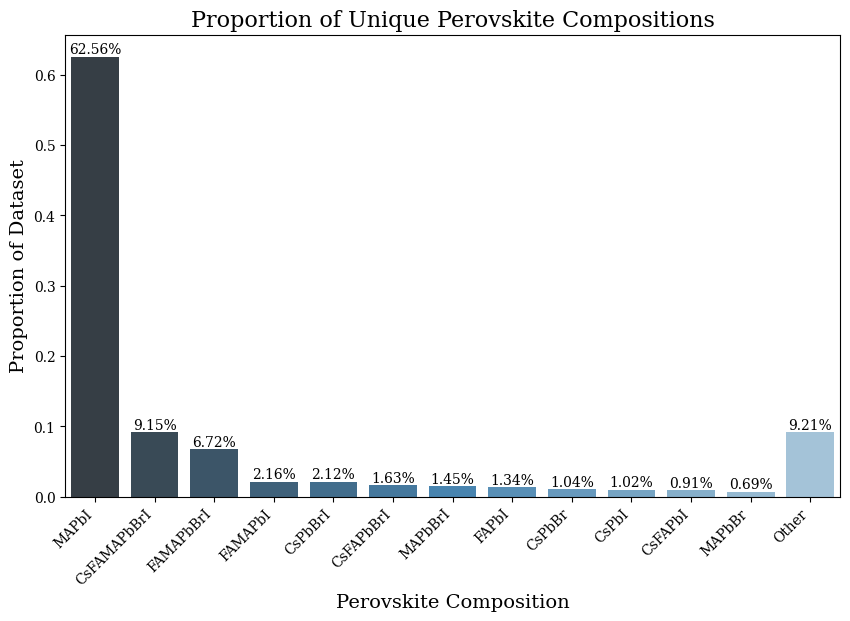

In [72]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Load data
filtered_df = pd.read_csv(r'C:\Users\c\OneDrive\Documents\PEROVSKITE PROJECT\PerovskiteML_project\Data\Perovsite database query.csv')

# Specify the column
col = 'Perovskite_composition_short_form'

# Count occurrences of each unique value
value_counts = filtered_df[col].value_counts()

# Get the top 12 most common compositions
top_12 = value_counts.nlargest(12)

# Sum up the remaining compositions into "Other"
other_sum = value_counts.iloc[12:].sum()

# Create a new DataFrame for plotting
plot_data = pd.concat([top_12, pd.Series(other_sum, index=['Other'])]).reset_index()
plot_data.columns = [col, 'count']

# Normalize to get proportions
plot_data['proportion'] = plot_data['count'] / value_counts.sum()

# Plot
plt.figure(figsize=(10, 6))
palette = sns.color_palette("Blues_d", len(plot_data))[::-1]
ax = sns.barplot(data=plot_data, x=col, y='proportion', palette=palette)

# Add title and labels
plt.title('Proportion of Unique Perovskite Compositions', fontsize=16)
plt.xlabel('Perovskite Composition', fontsize=14)
plt.ylabel('Proportion of Dataset', fontsize=14)
plt.xticks(rotation=45, ha='right')

# Add proportion values on top of the bars
for index, row in plot_data.iterrows():
    ax.text(index, row['proportion'], f"{row['proportion']:.2%}", ha='center', va='bottom')

plt.show()

Plotting PCE progress:

C:\Users\c\AppData\Local\Temp\ipykernel_9728\183417455.py:6: DtypeWarning: Columns (10,22,29,31,32,35,36,40,44,45,46,48,51,54,65,84,89,90,93,98,99,100,105,108,115,118,122,123,125,130,134,138,142,143,144,146,149,152,163,166,167,171,172,173,175,178,181,192,194,225,271,272,273,277,304,315,321,325,330,331,335,336,342,348,369,371,373,374,376,380,384,387,403,405,407,409) have mixed types. Specify dtype option on import or set low_memory=False.
  filtered_df = pd.read_csv(r'C:\Users\c\OneDrive\Documents\PEROVSKITE PROJECT\PerovskiteML_project\Data\Perovsite database query.csv')
C:\Users\c\AppData\Local\Temp\ipykernel_9728\183417455.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=max_pce_per_year, x='Year', y='JV_default_PCE', palette='Blues_d')


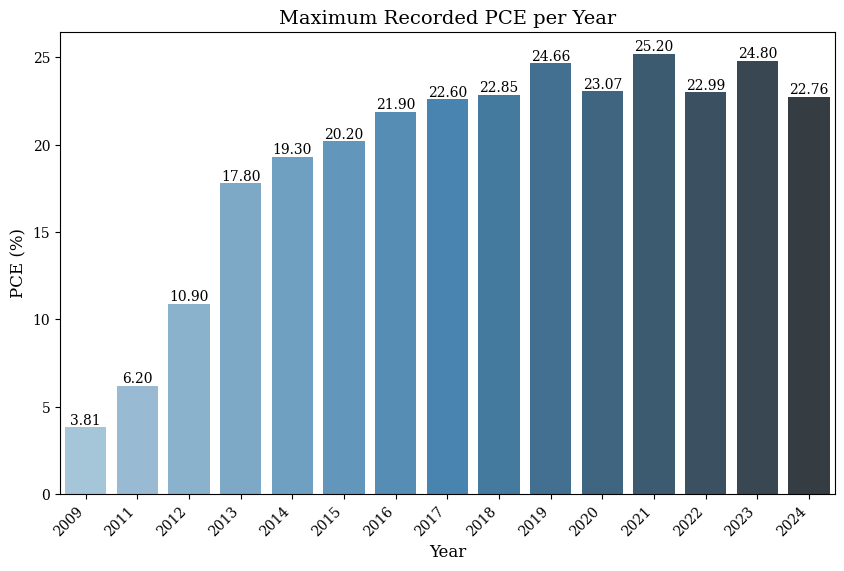

In [67]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Load data
filtered_df = pd.read_csv(r'C:\Users\c\OneDrive\Documents\PEROVSKITE PROJECT\PerovskiteML_project\Data\Perovsite database query.csv')

# Convert 'Ref_publish_date' to datetime format
filtered_df['Ref_publication_date'] = pd.to_datetime(filtered_df['Ref_publication_date'])

# Extract year
filtered_df['Year'] = filtered_df['Ref_publication_date'].dt.year

# Group by year and get the maximum PCE for each year
max_pce_per_year = filtered_df.groupby('Year')['JV_default_PCE'].max().reset_index()

# Plot the bar chart
plt.figure(figsize=(10, 6))
ax = sns.barplot(data=max_pce_per_year, x='Year', y='JV_default_PCE', palette='Blues_d')

# Add title and labels
plt.title('Maximum Recorded PCE per Year', fontsize=14)
plt.xlabel('Year', fontsize=12)
plt.ylabel('PCE (%)', fontsize=12)
plt.xticks(rotation=45, ha='right')

# Add value labels on top of the bars
for index, row in max_pce_per_year.iterrows():
    ax.text(index, row['JV_default_PCE'], f"{row['JV_default_PCE']:.2f}", ha='center', va='bottom')

plt.show()

Unique substrate, HTL, ETL, backcontact layers

C:\Users\c\AppData\Local\Temp\ipykernel_20340\1450624781.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=plot_df, x='Material', y='Proportion', palette='viridis', ax=ax)
C:\Users\c\AppData\Local\Temp\ipykernel_20340\1450624781.py:47: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(plot_df['Material'], rotation=45, ha='right')
C:\Users\c\AppData\Local\Temp\ipykernel_20340\1450624781.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=plot_df, x='Material', y='Proportion', palette='viridis', ax=ax)
C:\Users\c\AppData\Local\Temp\ipykernel_20340\1450624781.py:47: UserWarning: se

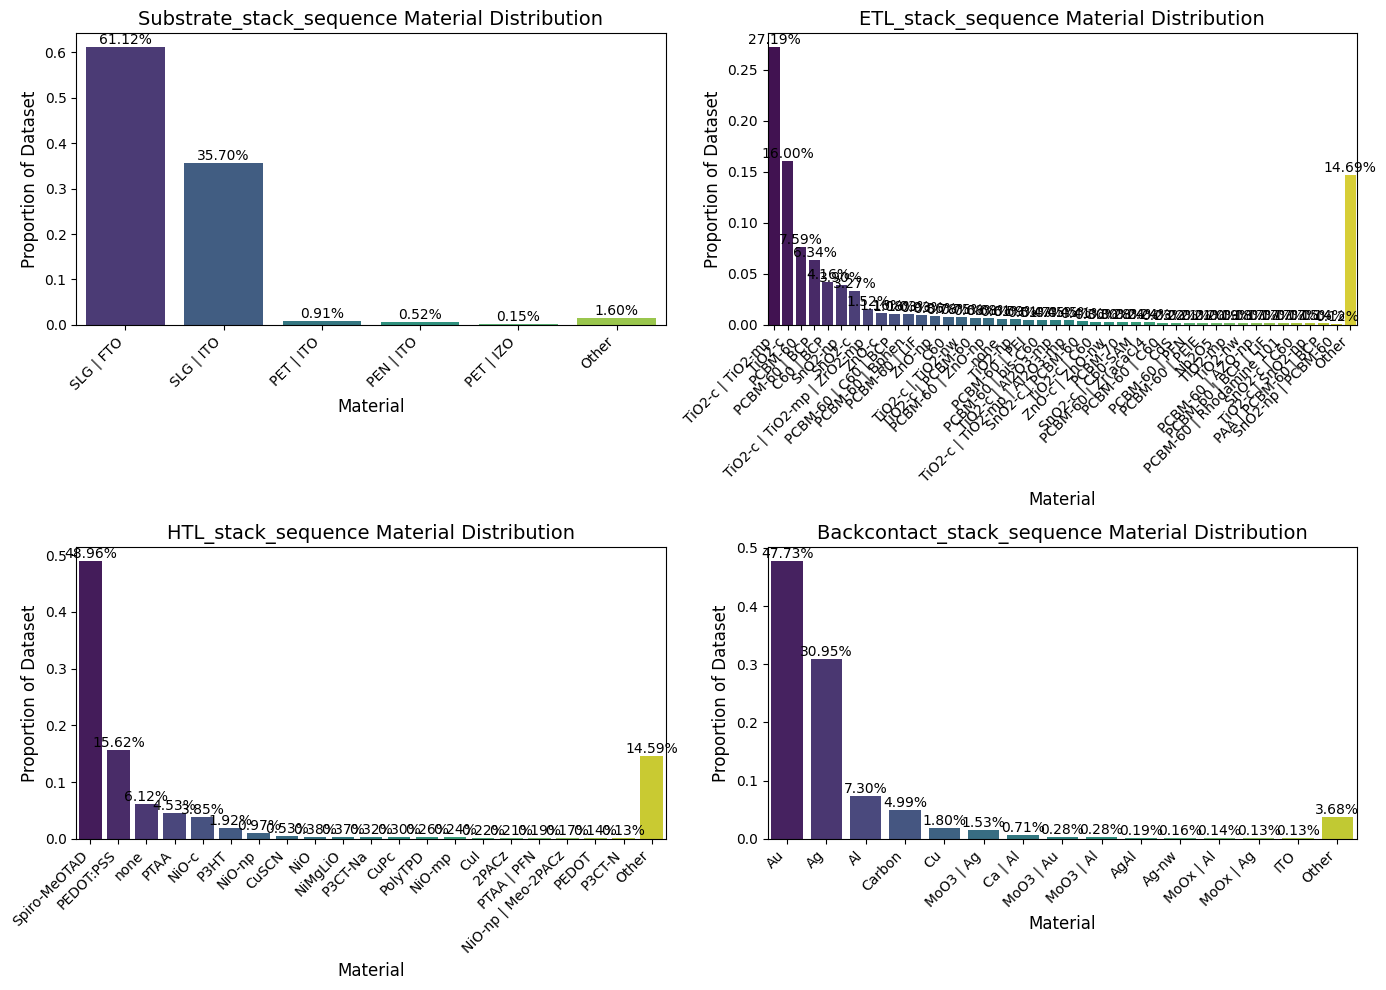

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Define the layers to analyze
columns = ['Substrate_stack_sequence', 'ETL_stack_sequence', 'HTL_stack_sequence', 'Backcontact_stack_sequence']

# Total number of rows in the dataset
total_rows = len(filtered_df)

# Threshold for grouping infrequent materials into "Other"
threshold = 50 / total_rows  # Convert threshold count to proportion

# Create subplots
fig, axes = plt.subplots(2, 2, figsize=(14, 10))  # 2x2 grid

# Loop through each layer and create a bar chart
for ax, col in zip(axes.flatten(), columns):
    # Count occurrences of each unique material
    value_counts = filtered_df[col].value_counts()
    
    # Normalize counts to get proportions
    value_counts_normalized = value_counts / total_rows
    
    # Identify less frequent materials to group into "Other"
    top_values = value_counts_normalized[value_counts_normalized >= threshold]
    other_proportion = value_counts_normalized[value_counts_normalized < threshold].sum()

    # Create final dataset for plotting
    plot_data = top_values.copy()
    if other_proportion > 0:
        plot_data['Other'] = other_proportion

    # Convert to DataFrame for seaborn
    plot_df = plot_data.reset_index()
    plot_df.columns = ['Material', 'Proportion']

    # Bar plot
    sns.barplot(data=plot_df, x='Material', y='Proportion', palette='viridis', ax=ax)

    # Labels and titles
    ax.set_title(f'{col} Material Distribution', fontsize=14)
    ax.set_xlabel('Material', fontsize=12)
    ax.set_ylabel('Proportion of Dataset', fontsize=12)

    # Rotate x-axis labels for readability
    ax.set_xticklabels(plot_df['Material'], rotation=45, ha='right')

    # Add proportion values above bars
    for index, row in plot_df.iterrows():
        ax.text(index, row['Proportion'], f"{row['Proportion']:.2%}", ha='center', va='bottom')

# Adjust layout
plt.tight_layout()
plt.show()



In [21]:
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
import pandas as pd

# Enable LaTeX rendering for all text in Matplotlib
matplotlib.rc('text', usetex=True)
matplotlib.rcParams['text.usetex'] = True
matplotlib.rcParams['text.latex.preamble'] = r'\usepackage{amsmath,amssymb}'

# Load data
filtered_df = pd.read_csv("Perovsite_database_query.csv")  # Update path if needed

# Define the column names for each layer and the top N materials to display
layers = {
    'Substrate stack sequence': 2,
    'ETL stack sequence': 2,
    'Backcontact stack sequence': 4
}

# Create subplots
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()  # Flatten axes array for easier indexing

for i, (layer, top_n) in enumerate(layers.items()):
    # Count occurrences of each material
    value_counts = filtered_df[layer].value_counts()
    total = value_counts.sum()

    # Get top N materials and sum up the remaining as "Other"
    top_materials = (value_counts.nlargest(top_n) / total) * 100
    other_sum = 100 - top_materials.sum()

    # Prepare data for plotting
    layer_df = pd.DataFrame(top_materials).reset_index()
    layer_df.columns = ['Material', 'Percentage']

    # Add 'Other' category
    if other_sum > 0:
        layer_df = pd.concat([layer_df, pd.DataFrame({'Material': [r'\textbf{Other}'], 'Percentage': [other_sum]})])

    # Use Seaborn for bar plot
    sns.barplot(data=layer_df, x='Material', y='Percentage', palette='viridis', ax=axes[i])

    # Set title and labels with LaTeX formatting
    axes[i].set_title(r'\textbf{' + layer.replace('_', ' ') + '}', fontsize=14)
    axes[i].set_xlabel(r'\textbf{Material}', fontsize=12)
    axes[i].set_ylabel(r'\text{Percentage (\%)}', fontsize=12)

    # Adjust x-axis for better readability
    axes[i].tick_params(axis='x', rotation=30)
    axes[i].set_xticklabels(layer_df['Material'], rotation=30, ha='right')

    # Set y-axis limit
    axes[i].set_ylim(0, 100)

# Adjust layout
plt.tight_layout()

# Enable LaTeX-style text rendering globally
plt.rc('text', usetex=True)
plt.rc('font', family='serif')

# Show the plot
plt.show()


FileNotFoundError: [Errno 2] No such file or directory: 'Perovsite_database_query.csv'

<>:58: SyntaxWarning: invalid escape sequence '\ '
<>:58: SyntaxWarning: invalid escape sequence '\ '
C:\Users\c\AppData\Local\Temp\ipykernel_9728\2182998626.py:58: SyntaxWarning: invalid escape sequence '\ '
  axes[i].set_title(r"$\bf{" + layer.replace("_", "\ ") + "}$", fontsize=24)
C:\Users\c\AppData\Local\Temp\ipykernel_9728\2182998626.py:7: DtypeWarning: Columns (10,22,29,31,32,35,36,40,44,45,46,48,51,54,65,84,89,90,93,98,99,100,105,108,115,118,122,123,125,130,134,138,142,143,144,146,149,152,163,166,167,171,172,173,175,178,181,192,194,225,271,272,273,277,304,315,321,325,330,331,335,336,342,348,369,371,373,374,376,380,384,387,403,405,407,409) have mixed types. Specify dtype option on import or set low_memory=False.
  filtered_df = pd.read_csv(r'C:\Users\c\OneDrive\Documents\PEROVSKITE PROJECT\PerovskiteML_project\Data\Perovsite database query.csv')
C:\Users\c\AppData\Local\Temp\ipykernel_9728\2182998626.py:55: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated

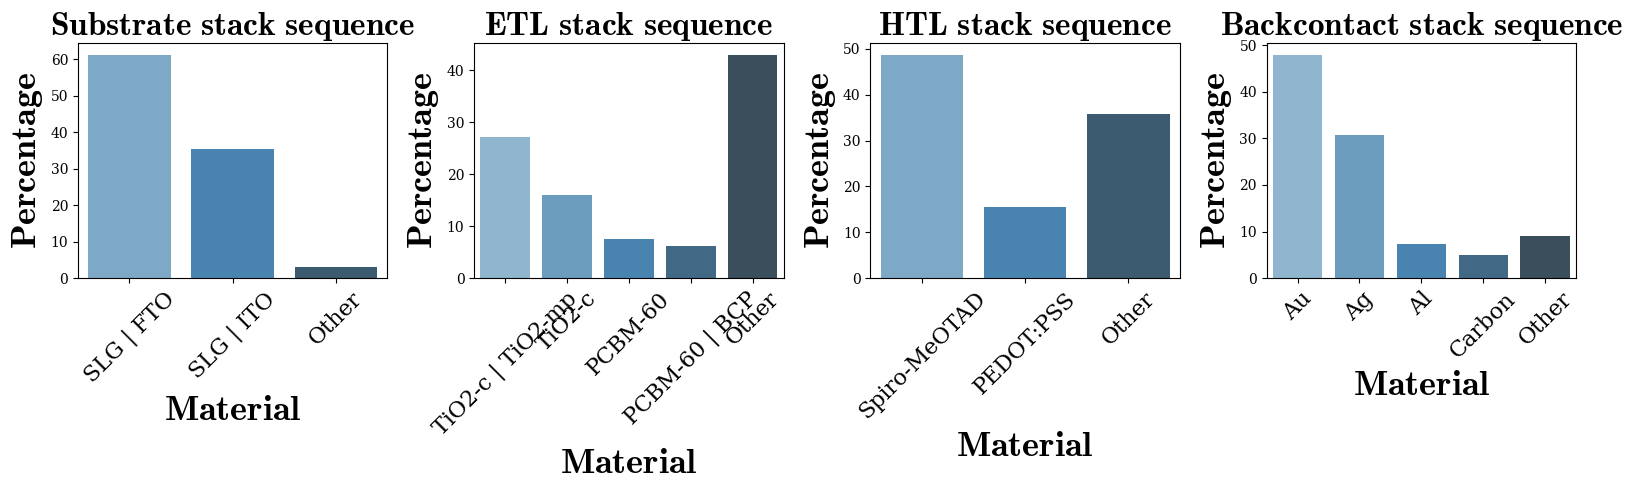

In [20]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Load data
filtered_df = pd.read_csv(r'C:\Users\c\OneDrive\Documents\PEROVSKITE PROJECT\PerovskiteML_project\Data\Perovsite database query.csv')

# Enable LaTeX-like font rendering (without needing full LaTeX)
plt.rcParams.update({
    'mathtext.fontset': 'cm',  # Use Computer Modern font for math text
    'font.family': 'serif',  # Use a LaTeX-like font
    'text.usetex': False  # Ensure full LaTeX is not required
})

# Define the layers and number of top materials
layers = {
    'Substrate_stack_sequence': 2,
    'ETL_stack_sequence': 4,
    'HTL_stack_sequence': 2,
    'Backcontact_stack_sequence': 4
}

custom_palette = sns.color_palette([
    (0.8, 0.9, 0.9),  # Light Blue
    (0.8, 0.8, 0.9),  # Sky Blue
    (0.7, 0.7, 0.9),  # Purple
    (0.5, 0.2, 0.7),  # Violet
    (0.9, 0.9, 1.0)   # Dark Purple
])

# Create subplots
# fig, axes = plt.subplots(2, 2, figsize=(12, 10))
# axes = axes.flatten()  

# Create subplots (1 row, 4 columns)
fig, axes = plt.subplots(1, 4, figsize=(16, 5), constrained_layout=False)

# Plot each layer separately
for i, (layer, top_n) in enumerate(layers.items()):
    value_counts = filtered_df[layer].value_counts()
    total = value_counts.sum()

    # Select top N materials and calculate percentage
    top_materials = value_counts.head(top_n)
    other_percentage = value_counts.iloc[top_n:].sum() / total * 100

    # Create DataFrame for plotting
    layer_df = pd.DataFrame({'Material': top_materials.index, 'Percentage': (top_materials / total) * 100})

    if other_percentage := (value_counts.iloc[top_n:].sum() / total) * 100:
        layer_df = pd.concat([layer_df, pd.DataFrame({'Material': ['Other'], 'Percentage': [other_percentage]})])

    # Seaborn bar plot
    sns.barplot(data=layer_df, x='Material', y='Percentage', palette='Blues_d', ax=axes[i])

    # Set LaTeX-like fonts for title and labels
    axes[i].set_title(r"$\bf{" + layer.replace("_", "\ ") + "}$", fontsize=24)
    axes[i].set_xlabel(r"$\bf{Material}$", fontsize=26)
    axes[i].set_ylabel(r"$\bf{Percentage}$", fontsize=26)
    axes[i].tick_params(axis='x', rotation=45, labelsize=16)

plt.tight_layout()
plt.show()


c:\Users\c\miniconda3\envs\test-env\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: constrained_layout not applied because axes sizes collapsed to zero.  Try making figure larger or Axes decorations smaller.
  fig.canvas.print_figure(bytes_io, **kw)


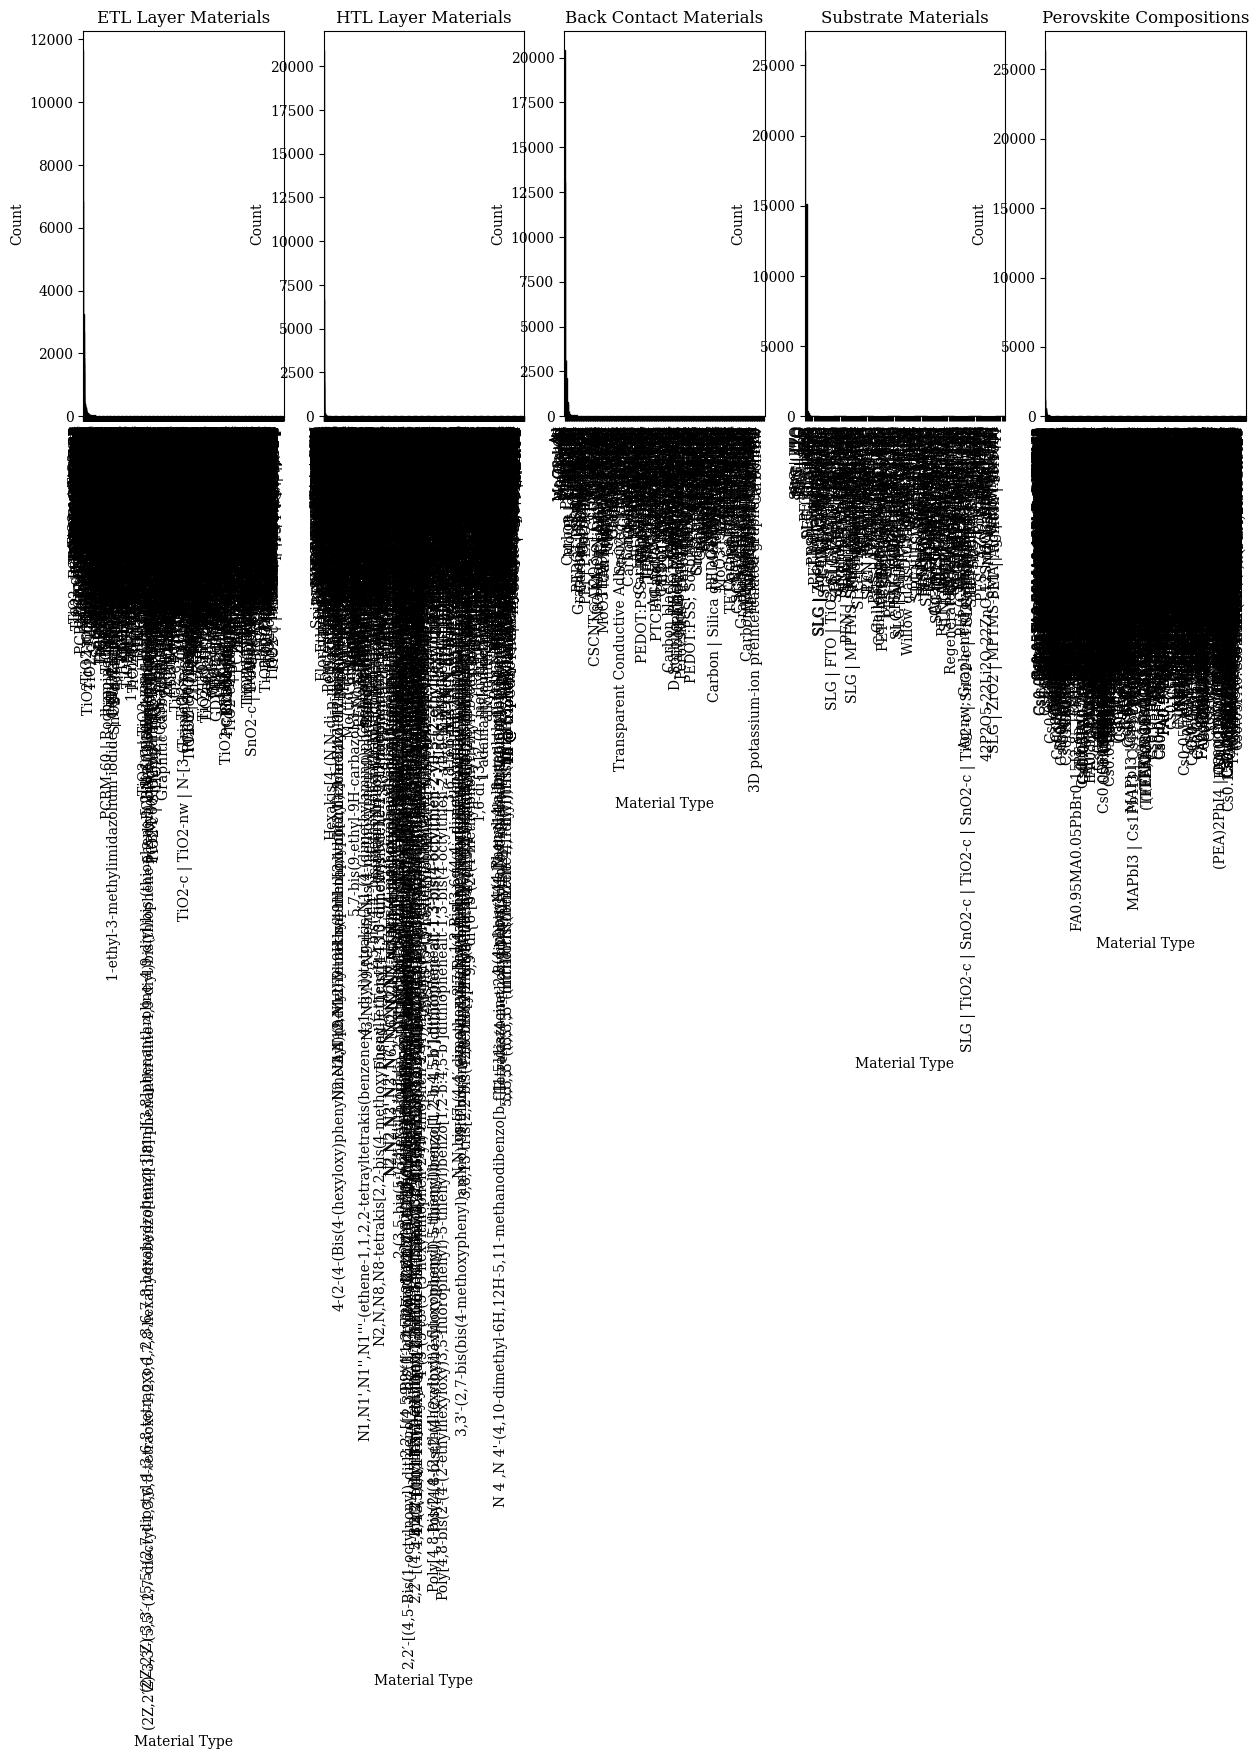

In [70]:
import matplotlib.pyplot as plt

# Define the columns and their custom titles
columns = {
    'ETL_stack_sequence': 'ETL Layer Materials',
    'HTL_stack_sequence': 'HTL Layer Materials',
    'Backcontact_stack_sequence': 'Back Contact Materials',
    'Substrate_stack_sequence': 'Substrate Materials',
    'Perovskite_composition_long_form': 'Perovskite Compositions'
}

# Set up subplots
fig, axes = plt.subplots(1, len(columns), figsize=(15, 5), constrained_layout=True)

# Loop through each column and create a bar plot
for ax, (col, title) in zip(axes, columns.items()):
    unique_counts = filtered_df[col].value_counts().sort_values(ascending=False)
    
    # Plot bar chart
    unique_counts.plot(kind='bar', ax=ax, color='skyblue', edgecolor='black')
    
    # Set titles and labels
    ax.set_title(title)
    ax.set_xlabel('Material Type')
    ax.set_ylabel('Count')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=90, ha='right')

# Show the plot
plt.show()

Correlation analysis:

Correlation coefficient between Perovskite_band_gap and JV_default_PCE: -0.09


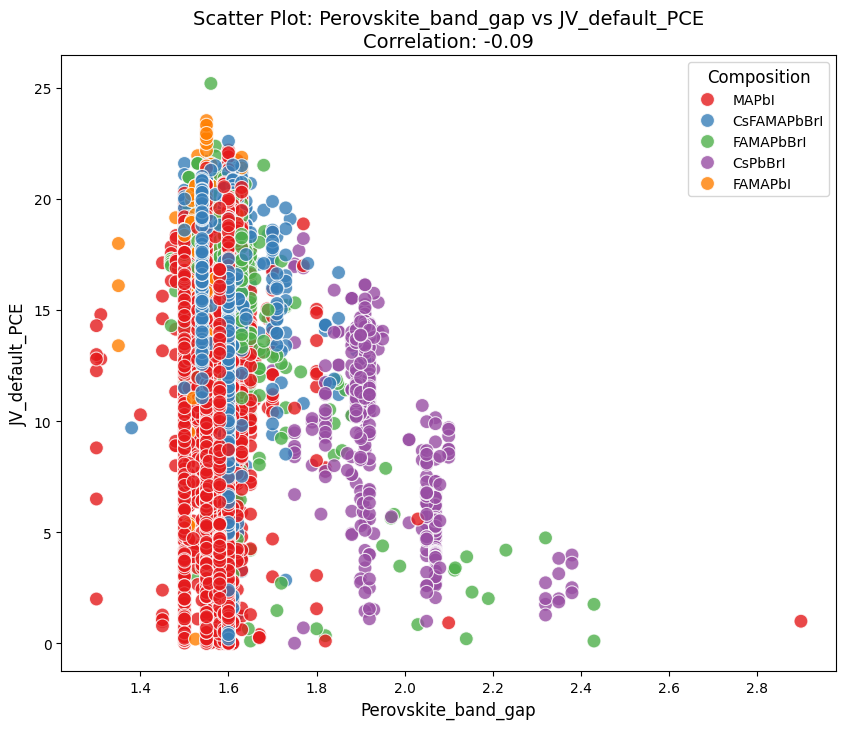

In [36]:
# plot band gap vs PCE for the top 5 most common configurations (any configuration that makes up 2%+ of the total dataset

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Filter the DataFrame for specific values in 'Perovskite_composition_short_form'
filtered_df = filtered_df[
    filtered_df['Perovskite_composition_short_form'].isin(
        ['MAPbI', 'CsFAMAPbBrI', 'FAMAPbBrI', 'FAMAPbI', 'CsPbBrI']
    )
]

# Specify the columns to plot
x_col = 'Perovskite_band_gap'
y_col = 'JV_default_PCE'

# Calculate the correlation coefficient
correlation = filtered_df[[x_col, y_col]].corr().iloc[0, 1]
print(f"Correlation coefficient between {x_col} and {y_col}: {correlation:.2f}")

# Create the scatter plot
plt.figure(figsize=(10, 8))
sns.scatterplot(
    data=filtered_df,
    x=x_col,
    y=y_col,
    hue='Perovskite_composition_short_form',  # Use this column for color coding
    palette='Set1',  # Choose a palette with distinct colors
    s=100,  # Size of scatter points
    alpha=0.8,  # Transparency
)

# Add title and labels, including the correlation coefficient
plt.title(f'Scatter Plot: {x_col} vs {y_col}\nCorrelation: {correlation:.2f}', fontsize=14)
plt.xlabel(x_col, fontsize=12)
plt.ylabel(y_col, fontsize=12)
plt.legend(title='Composition', fontsize=10, title_fontsize=12)

# Display the plot
plt.show()


C:\Users\c\AppData\Local\Temp\ipykernel_9608\2709337528.py:1: DtypeWarning: Columns (18,19) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(r'C:\Users\c\OneDrive\Documents\PEROVSKITE PROJECT\PerovskiteML_project\EDA\filtered_original_data.csv')


                                 JV_default_PCE  JV_default_Voc  \
JV_default_PCE                         1.000000        0.603160   
JV_default_Voc                         0.603160        1.000000   
JV_default_Jsc                         0.810310        0.380885   
JV_default_FF                          0.750089        0.516729   
JV_hysteresis_index                   -0.030330       -0.090256   
Stability_PCE_end_of_experiment        0.077729        0.080693   

                                 JV_default_Jsc  JV_default_FF  \
JV_default_PCE                         0.810310       0.750089   
JV_default_Voc                         0.380885       0.516729   
JV_default_Jsc                         1.000000       0.475439   
JV_default_FF                          0.475439       1.000000   
JV_hysteresis_index                   -0.087698      -0.044277   
Stability_PCE_end_of_experiment       -0.009570       0.066160   

                                 JV_hysteresis_index  \
JV_default_

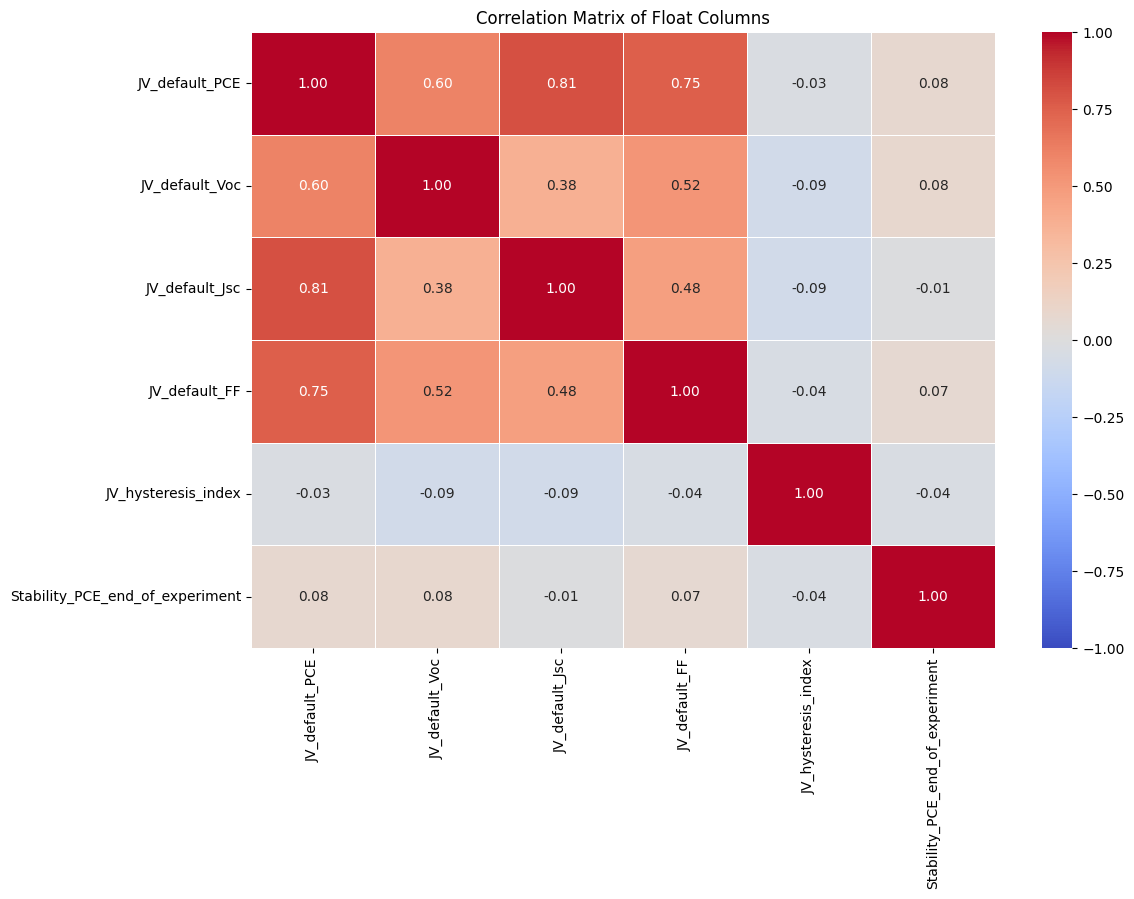

In [5]:
df = pd.read_csv(r'C:\Users\c\OneDrive\Documents\PEROVSKITE PROJECT\PerovskiteML_project\EDA\filtered_original_data.csv')

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Select only float columns
float_cols = df.select_dtypes(include=['float64', 'float32']).columns
df_floats = df[float_cols]

# Compute the correlation matrix for float columns only
corr_matrix = df_floats.corr()

# # Display correlation matrix
# print(corr_matrix)

# Plot heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5, vmin=-1, vmax=1)
plt.title("Correlation Matrix of Float Columns")
plt.show()

                                 JV_default_PCE  JV_default_Voc  \
JV_default_PCE                         1.000000        0.692519   
JV_default_Voc                         0.692519        1.000000   
JV_default_Jsc                         0.811679        0.361309   
JV_default_FF                          0.364629        0.247030   
JV_hysteresis_index                   -0.009157        0.024040   
Stability_PCE_end_of_experiment        0.101533        0.081401   
MA                                    -0.113102       -0.218437   
FA                                     0.216223        0.168455   
Cs                                    -0.173443        0.152752   
Br                                    -0.157197        0.282808   
I                                      0.157197       -0.282808   

                                 JV_default_Jsc  JV_default_FF  \
JV_default_PCE                         0.811679       0.364629   
JV_default_Voc                         0.361309       0.247030 

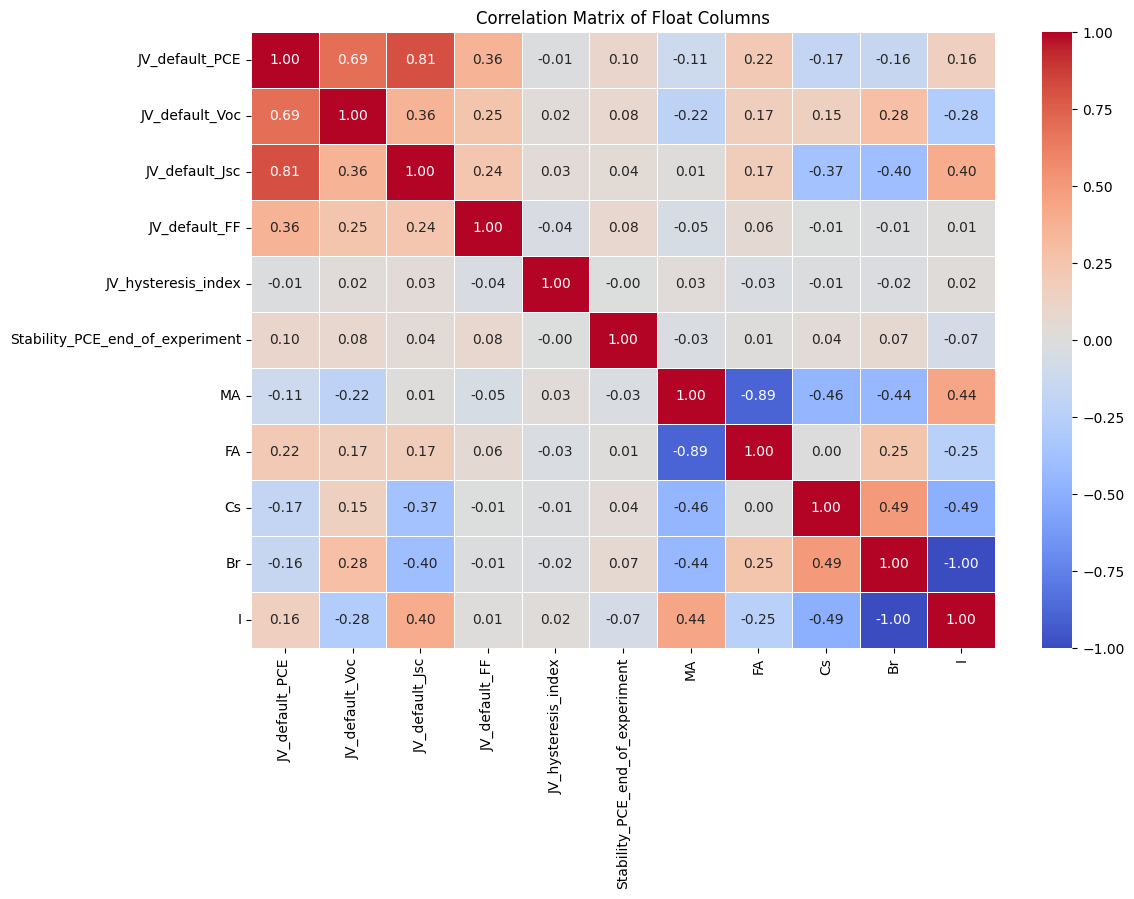

In [7]:
df = pd.read_csv(r'C:\Users\c\OneDrive\Documents\PEROVSKITE PROJECT\PerovskiteML_project\Regression model\cleaned_data_for_regression.csv')

columns_to_plot = ['JV_default_PCE', 'JV_default_Voc', 'JV_default_Jsc', 'JV_default_FF', 'JV_hysteresis_index', 
'Stability_PCE_end_of_experiment', 'MA', 'FA', 'Cs', 'Br', 'I']

####### haven't included Pb because its always 1 in this case ######

df = df[columns_to_plot]

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Compute the correlation matrix for float columns only
corr_matrix = df.corr()

# Display correlation matrix
print(corr_matrix)

# Plot heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5, vmin=-1, vmax=1)
plt.title("Correlation Matrix of Float Columns")
plt.show()

In [53]:
# Calculate the threshold for 10% of columns
threshold = int(0.1 * filtered_df.shape[1])

# Count rows with 10% or fewer missing or zero values
valid_rows = filtered_df.apply(lambda row: ((row == 0) | (row.isnull())).sum(), axis=1) <= threshold

# Print the count of such rows
print(f"Number of rows with 10% or fewer missing/zero values: {valid_rows.sum()}")



Number of rows with 10% or fewer missing/zero values: 50
